# 🎬 IMDb Movies — Exploratory Data Analysis

> **Author:** Portfolio Project  
> **Dataset:** `imdb_movies.csv` — ~1 000 recent theatrical releases  
> **Goal:** Extract actionable insights about what drives audience scores,
> box-office performance, and genre trends.

---

## Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Quality & Cleaning](#2-data-quality--cleaning)
3. [Score Distribution](#3-score-distribution)
4. [Scores Over Time](#4-scores-over-time)
5. [Production Volume Over Time](#5-production-volume-over-time)
6. [Genre Analysis](#6-genre-analysis)
7. [Budget × Revenue × Score](#7-budget--revenue--score)
8. [Country of Origin](#8-country-of-origin)
9. [Language Breakdown](#9-language-breakdown)
10. [Conclusions](#10-conclusions)


---
## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── visual theme ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

ACCENT   = '#E63946'   # red  — main highlight
BLUE     = '#457B9D'   # blue — secondary
TEAL     = '#2A9D8F'   # teal — tertiary
PALETTE  = sns.color_palette('tab10')


In [2]:
df_raw = pd.read_csv('../data/imdb_movies.csv')

print(f'Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape : 10,178 rows × 12 columns
Columns: ['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title', 'status', 'orig_lang', 'budget_x', 'revenue', 'country']


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU


---
## 2. Data Quality & Cleaning

Before any analysis we document the data-quality issues found and the decisions made to address them.

In [3]:
# ── 2a. Missing-value audit ──────────────────────────────────────────
missing = (
    df_raw.isna().sum()
    .rename('missing')
    .to_frame()
    .assign(pct=lambda d: (d['missing'] / len(df_raw) * 100).round(1))
    .sort_values('missing', ascending=False)
)
print(missing.to_string())

            missing  pct
genre            85  0.8
crew             56  0.6
names             0  0.0
date_x            0  0.0
score             0  0.0
overview          0  0.0
orig_title        0  0.0
status            0  0.0
orig_lang         0  0.0
budget_x          0  0.0
revenue           0  0.0
country           0  0.0


### Cleaning decisions

| Issue | Decision | Rationale |
|---|---|---|
| `score == 0` | Drop rows | Score of 0 means *unrated*, not a genuine zero |
| `budget_x == 0` | Keep rows but flag; exclude from budget analyses | Many legitimate films have no budget data |
| `date_x` (string) | Parse to datetime, extract `year` | Enables temporal analyses |
| `genre` (multi-label) | Explode on `', '` for per-genre stats | Each film can belong to multiple genres |
| Rows missing `score`, `genre`, or `date_x` | Drop | Too little info for analysis |


In [4]:
df = df_raw.copy()

# ── Step 1: Remove unrated films ─────────────────────────────────────
before = len(df)
df = df[df['score'] > 0]
print(f'Dropped {before - len(df):,} unrated rows (score == 0)')

# ── Step 2: Parse dates, extract year ────────────────────────────────
df['date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['year'] = df['date'].dt.year

# ── Step 3: Drop rows missing critical columns ────────────────────────
before = len(df)
df = df.dropna(subset=['score', 'genre', 'date'])
print(f'Dropped {before - len(df):,} rows missing score/genre/date')

# ── Step 4: Tidy dtypes & rename for clarity ──────────────────────────
df = df.rename(columns={'budget_x': 'budget', 'orig_lang': 'language'})
df['budget']  = pd.to_numeric(df['budget'],  errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['score']   = df['score'].astype(float)

# ── Step 5: Derive ROI (only where both budget & revenue are valid) ───
mask_valid = (df['budget'] > 0) & (df['revenue'] > 0)
df.loc[mask_valid, 'roi'] = df.loc[mask_valid, 'revenue'] / df.loc[mask_valid, 'budget']

print(f'\nClean dataset: {len(df):,} films')
print(f'Year range   : {int(df.year.min())} – {int(df.year.max())}')
print(f'Score range  : {df.score.min():.1f} – {df.score.max():.1f}')
df.dtypes

Dropped 211 unrated rows (score == 0)
Dropped 44 rows missing score/genre/date

Clean dataset: 9,923 films
Year range   : 1903 – 2023
Score range  : 10.0 – 100.0


names                 object
date_x                object
score                float64
genre                 object
overview              object
crew                  object
orig_title            object
status                object
language              object
budget               float64
revenue              float64
country               object
date          datetime64[ns]
year                   int32
roi                  float64
dtype: object

---
## 3. Score Distribution

We examine how audience scores are distributed across the dataset, including the overall shape and key percentiles.

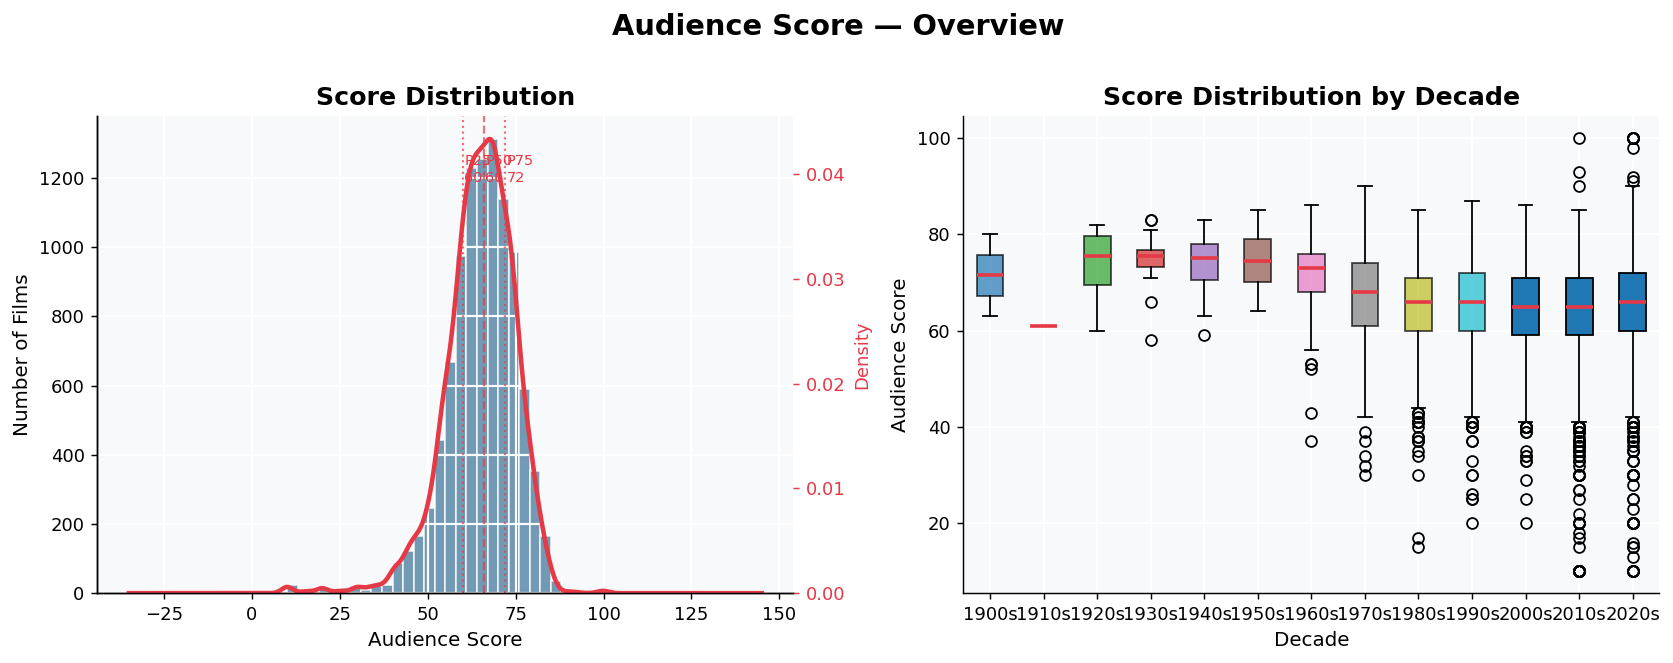

count    9923.00
mean       64.89
std         9.89
min        10.00
25%        60.00
50%        66.00
75%        72.00
max       100.00

Skewness : -1.024
Kurtosis : 3.386

💡 Distribution is slightly left-skewed — most films cluster between 60–80; very low scores are rare.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: histogram + KDE ────────────────────────────────────────────
ax = axes[0]
ax.hist(df['score'], bins=30, color=BLUE, alpha=0.75, edgecolor='white', label='Films')
ax2 = ax.twinx()
df['score'].plot.kde(ax=ax2, color=ACCENT, linewidth=2.5, label='KDE')
ax2.set_ylabel('Density', color=ACCENT, fontsize=10)
ax2.tick_params(axis='y', colors=ACCENT)
ax2.set_ylim(bottom=0)
ax2.grid(False)
# percentile markers
for p, ls in zip([25, 50, 75], [':', '--', ':']):
    val = np.percentile(df['score'], p)
    ax.axvline(val, color=ACCENT, linestyle=ls, linewidth=1.2, alpha=0.7)
    ax.text(val + 0.4, ax.get_ylim()[1]*0.92, f'P{p}\n{val:.0f}',
            fontsize=8, color=ACCENT, va='top')
ax.set_xlabel('Audience Score')
ax.set_ylabel('Number of Films')
ax.set_title('Score Distribution')

# ── Right: box-plot by rounded decade ────────────────────────────────
ax = axes[1]
df_box = df.copy()
df_box['decade'] = (df_box['year'] // 10 * 10).astype(int)
decades = sorted(df_box['decade'].unique())
data_by_decade = [df_box.loc[df_box['decade'] == d, 'score'] for d in decades]
bp = ax.boxplot(data_by_decade, patch_artist=True,
                medianprops=dict(color=ACCENT, linewidth=2))
for patch, col in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticklabels([f"{d}s" for d in decades])
ax.set_xlabel('Decade')
ax.set_ylabel('Audience Score')
ax.set_title('Score Distribution by Decade')

fig.suptitle('Audience Score — Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────
print(df['score'].describe().round(2).to_string())
print(f'\nSkewness : {df["score"].skew():.3f}')
print(f'Kurtosis : {df["score"].kurtosis():.3f}')
print('\n💡 Distribution is slightly left-skewed — most films cluster'
      ' between 60–80; very low scores are rare.')

---
## 4. Scores Over Time

Do audiences rate films higher or lower as years pass? We look at both the mean and the confidence interval.

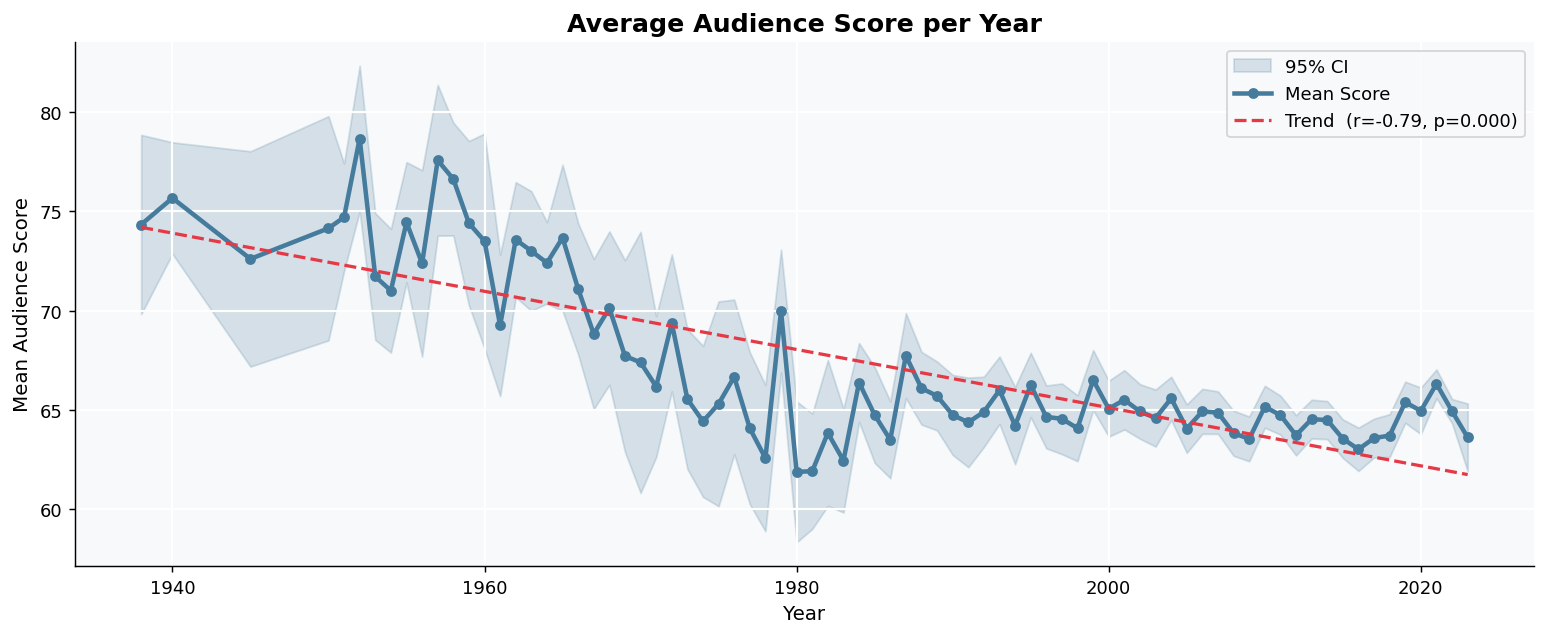

Trend: downward (-0.15 pts/year), statistically significant (p=0.000)


In [6]:
yearly = (
    df.groupby('year')['score']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
yearly['se']    = yearly['std'] / np.sqrt(yearly['n'])
yearly['ci95']  = yearly['se'] * 1.96

# Keep only years with ≥5 films for reliability
yearly = yearly[yearly['n'] >= 5]

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(yearly['year'],
                yearly['mean'] - yearly['ci95'],
                yearly['mean'] + yearly['ci95'],
                color=BLUE, alpha=0.2, label='95% CI')
ax.plot(yearly['year'], yearly['mean'],
        color=BLUE, linewidth=2.5, marker='o', markersize=5, label='Mean Score')

# regression line
slope, intercept, r, p, _ = stats.linregress(yearly['year'], yearly['mean'])
x_fit = np.array([yearly['year'].min(), yearly['year'].max()])
ax.plot(x_fit, intercept + slope * x_fit,
        color=ACCENT, linestyle='--', linewidth=1.8,
        label=f'Trend  (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Year')
ax.set_ylabel('Mean Audience Score')
ax.set_title('Average Audience Score per Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

plt.tight_layout()
plt.show()

direction = 'upward' if slope > 0 else 'downward'
sig = 'statistically significant' if p < 0.05 else 'not statistically significant'
print(f'Trend: {direction} ({slope:+.2f} pts/year), {sig} (p={p:.3f})')

---
## 5. Production Volume Over Time

How many films are released each year in the dataset? Note that very recent years may appear lower simply because data collection lags behind theatrical release dates.

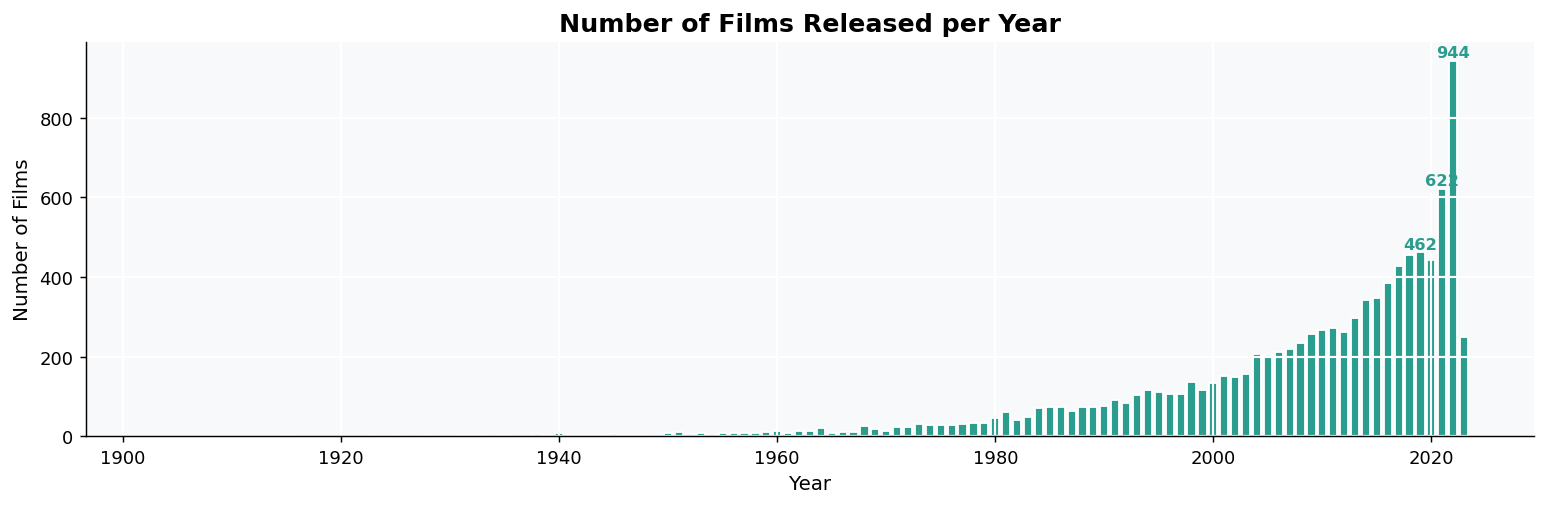

 year  count
 2022    944
 2021    622
 2019    462
 2018    456
 2020    444


In [7]:
vol = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.bar(vol['year'], vol['count'], color=TEAL, edgecolor='white', width=0.75)

# annotate the top 3 years
for _, row in vol.nlargest(3, 'count').iterrows():
    ax.text(row['year'], row['count'] + 1, f"{int(row['count'])}",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=TEAL)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Films')
ax.set_title('Number of Films Released per Year')

plt.tight_layout()
plt.show()

print(vol.sort_values('count', ascending=False).head(5).to_string(index=False))

---
## 6. Genre Analysis

Films carry multiple genre tags. We *explode* the genre column so each tag becomes a separate row, allowing proper per-genre aggregation.

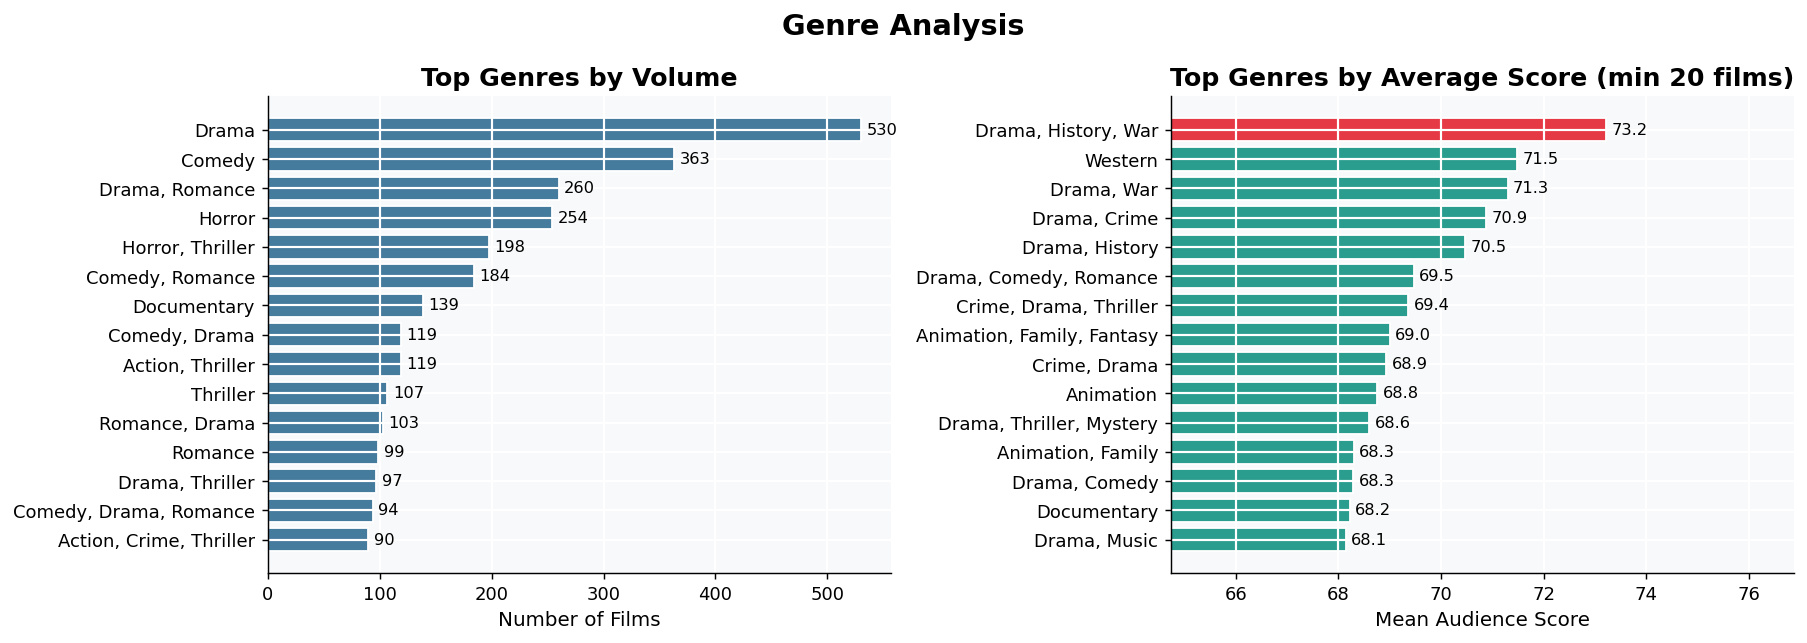

Top 10 genres by mean score:
                     genre  count      mean  median
       Drama, History, War     27 73.222222    75.0
                   Western     29 71.482759    71.0
                Drama, War     30 71.300000    73.0
              Drama, Crime     42 70.880952    70.5
            Drama, History     85 70.470588    71.0
    Drama, Comedy, Romance     30 69.466667    70.5
    Crime, Drama, Thriller     58 69.362069    69.5
Animation, Family, Fantasy     22 69.000000    68.5
              Crime, Drama     45 68.933333    72.0
                 Animation     29 68.758621    70.0


In [8]:
# ── Build exploded genre frame ───────────────────────────────────────
df_genre = (
    df.assign(genre=df['genre'].str.split(', '))
    .explode('genre')
)
df_genre['genre'] = df_genre['genre'].str.strip()

genre_stats = (
    df_genre.groupby('genre')['score']
    .agg(count='count', mean='mean', median='median')
    .reset_index()
    .query('count >= 20')  # require ≥20 films for reliability
    .sort_values('mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: film count per genre ────────────────────────────────────────
top_by_vol = genre_stats.sort_values('count', ascending=True).tail(15)
ax = axes[0]
bars = ax.barh(top_by_vol['genre'], top_by_vol['count'],
               color=BLUE, edgecolor='white')
ax.set_xlabel('Number of Films')
ax.set_title('Top Genres by Volume')
ax.bar_label(bars, padding=3, fontsize=9)

# ── Right: mean score per genre ───────────────────────────────────────
top_by_score = genre_stats.sort_values('mean', ascending=True).tail(15)
colors_g = [ACCENT if v == top_by_score['mean'].max() else TEAL
            for v in top_by_score['mean']]
ax = axes[1]
bars = ax.barh(top_by_score['genre'], top_by_score['mean'],
               color=colors_g, edgecolor='white')
ax.set_xlabel('Mean Audience Score')
ax.set_title('Top Genres by Average Score (min 20 films)')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlim(left=top_by_score['mean'].min() * 0.95)

fig.suptitle('Genre Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 genres by mean score:')
print(genre_stats.head(10)[['genre','count','mean','median']].to_string(index=False))

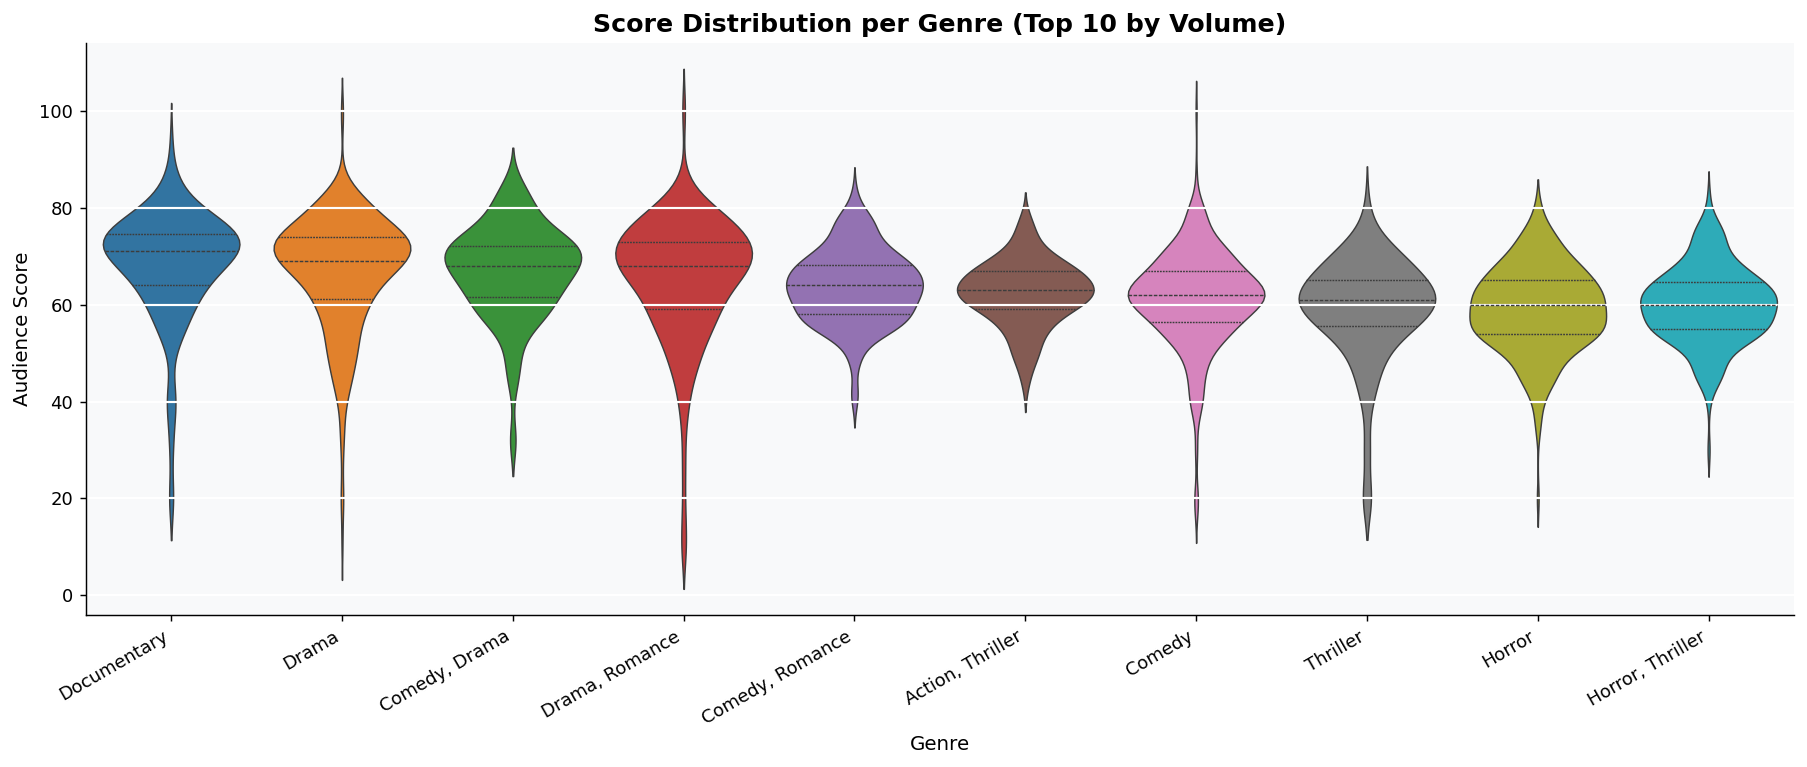

In [9]:
# ── Score distribution violin per genre (top 10 by volume) ──────────
top10 = (
    genre_stats.sort_values('count', ascending=False)
    .head(10)['genre'].tolist()
)
df_violin = df_genre[df_genre['genre'].isin(top10)]

order = (
    df_violin.groupby('genre')['score'].median()
    .sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=df_violin, x='genre', y='score',
    order=order, palette='tab10',
    inner='quartile', linewidth=0.8, ax=ax
)
ax.set_xlabel('Genre')
ax.set_ylabel('Audience Score')
ax.set_title('Score Distribution per Genre (Top 10 by Volume)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Budget × Revenue × Score

Do expensive films score better? Does spending more guarantee profit? We restrict this analysis to films with **positive** budget and revenue figures.

In [10]:
df_fin = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df_fin['roi']          = df_fin['revenue'] / df_fin['budget']
df_fin['profit']       = df_fin['revenue'] - df_fin['budget']
df_fin['profitable']   = df_fin['profit'] > 0

print(f'Films with budget & revenue data : {len(df_fin):,}')
print(f'Profitable (revenue > budget)    : {df_fin["profitable"].sum():,}'
      f' ({df_fin["profitable"].mean()*100:.1f}%)')

Films with budget & revenue data : 9,851
Profitable (revenue > budget)    : 8,054 (81.8%)


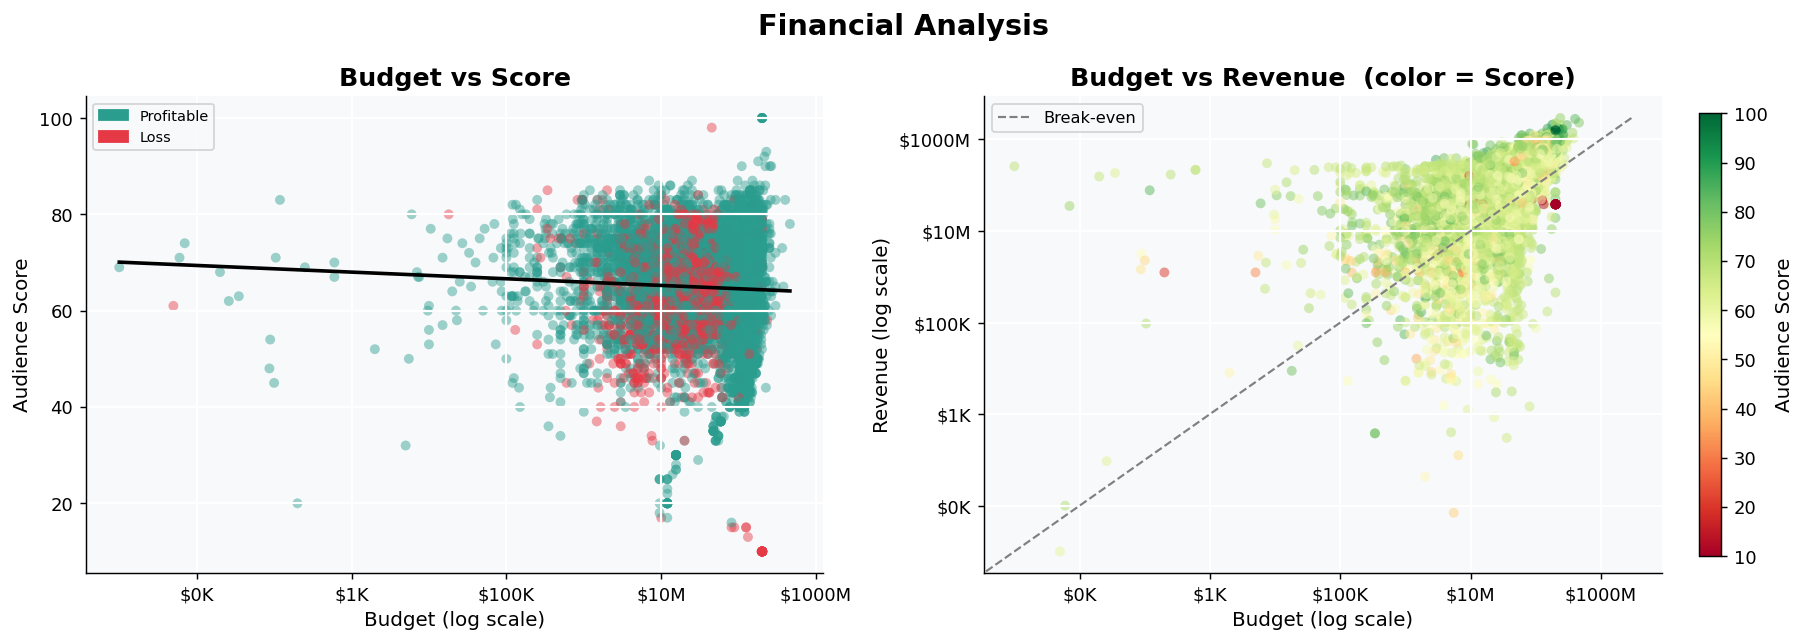

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Budget vs Score (log x-axis) ───────────────────────────────
ax = axes[0]
ax.scatter(
    df_fin['budget'], df_fin['score'],
    c=df_fin['profitable'].map({True: TEAL, False: ACCENT}),
    alpha=0.45, s=30, linewidths=0
)
# regression on log-budget
log_budget = np.log10(df_fin['budget'])
slope, intercept, r, p, _ = stats.linregress(log_budget, df_fin['score'])
x_range = np.linspace(log_budget.min(), log_budget.max(), 200)
ax.plot(10**x_range, intercept + slope * x_range,
        color='black', linewidth=2,
        label=f'Trend (r={r:.2f}, p={p:.3f})')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.0f}M' if v >= 1e6 else f'${v/1e3:.0f}K'))
ax.set_xlabel('Budget (log scale)')
ax.set_ylabel('Audience Score')
ax.set_title('Budget vs Score')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=TEAL,   label='Profitable'),
    Patch(color=ACCENT, label='Loss'),
], loc='upper left', fontsize=8)

# ── Right: Budget vs Revenue ──────────────────────────────────────────
ax = axes[1]
ax.scatter(
    df_fin['budget'], df_fin['revenue'],
    c=df_fin['score'], cmap='RdYlGn',
    alpha=0.5, s=30, linewidths=0
)
# break-even line
lim = max(df_fin['budget'].max(), df_fin['revenue'].max())
ax.plot([0, lim], [0, lim], color='grey', linestyle='--',
        linewidth=1.2, label='Break-even')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.0f}M' if v >= 1e6 else f'${v/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.0f}M' if v >= 1e6 else f'${v/1e3:.0f}K'))
ax.set_xlabel('Budget (log scale)')
ax.set_ylabel('Revenue (log scale)')
ax.set_title('Budget vs Revenue  (color = Score)')
ax.legend(fontsize=9)

sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                           norm=plt.Normalize(df_fin['score'].min(),
                                              df_fin['score'].max()))
fig.colorbar(sm, ax=axes[1], label='Audience Score', fraction=0.03)

fig.suptitle('Financial Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

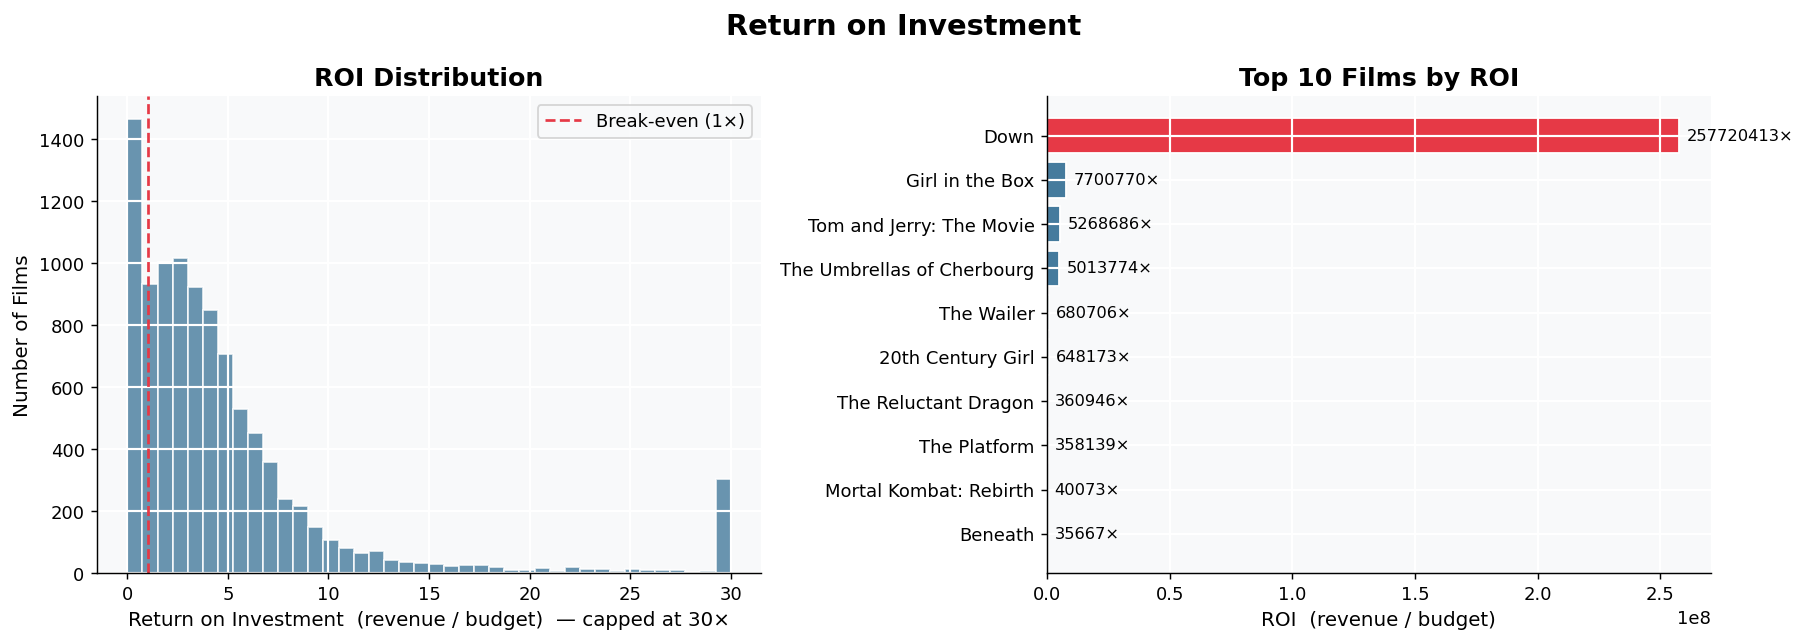

Top 10 ROI films:
                     names          roi  score
                      Down 2.577204e+08   69.0
           Girl in the Box 7.700770e+06   68.0
  Tom and Jerry: The Movie 5.268686e+06   63.0
The Umbrellas of Cherbourg 5.013774e+06   74.0
                The Wailer 6.807062e+05   69.0
         20th Century Girl 6.481730e+05   83.0
      The Reluctant Dragon 3.609463e+05   67.0
              The Platform 3.581391e+05   70.0
    Mortal Kombat: Rebirth 4.007296e+04   67.0
                   Beneath 3.566692e+04   54.0


In [12]:
# ── ROI distribution & top 10 by ROI ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROI histogram (capped at 30x for readability)
ax = axes[0]
roi_cap = df_fin['roi'].clip(upper=30)
ax.hist(roi_cap, bins=40, color=BLUE, edgecolor='white', alpha=0.8)
ax.axvline(1, color=ACCENT, linestyle='--', linewidth=1.5, label='Break-even (1×)')
ax.set_xlabel('Return on Investment  (revenue / budget)  — capped at 30×')
ax.set_ylabel('Number of Films')
ax.set_title('ROI Distribution')
ax.legend()

# Top 10 by ROI
ax = axes[1]
top_roi = df_fin.nlargest(10, 'roi')[['names','roi','score']].reset_index(drop=True)
colors_r = [ACCENT if i == 0 else BLUE for i in range(len(top_roi))]
bars = ax.barh(top_roi['names'], top_roi['roi'],
               color=colors_r, edgecolor='white')
ax.bar_label(bars, fmt='%.0f×', padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('ROI  (revenue / budget)')
ax.set_title('Top 10 Films by ROI')

fig.suptitle('Return on Investment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 ROI films:')
print(top_roi.to_string(index=False))

---
## 8. Country of Origin

Where are the films produced? Does country of origin correlate with audience scores?

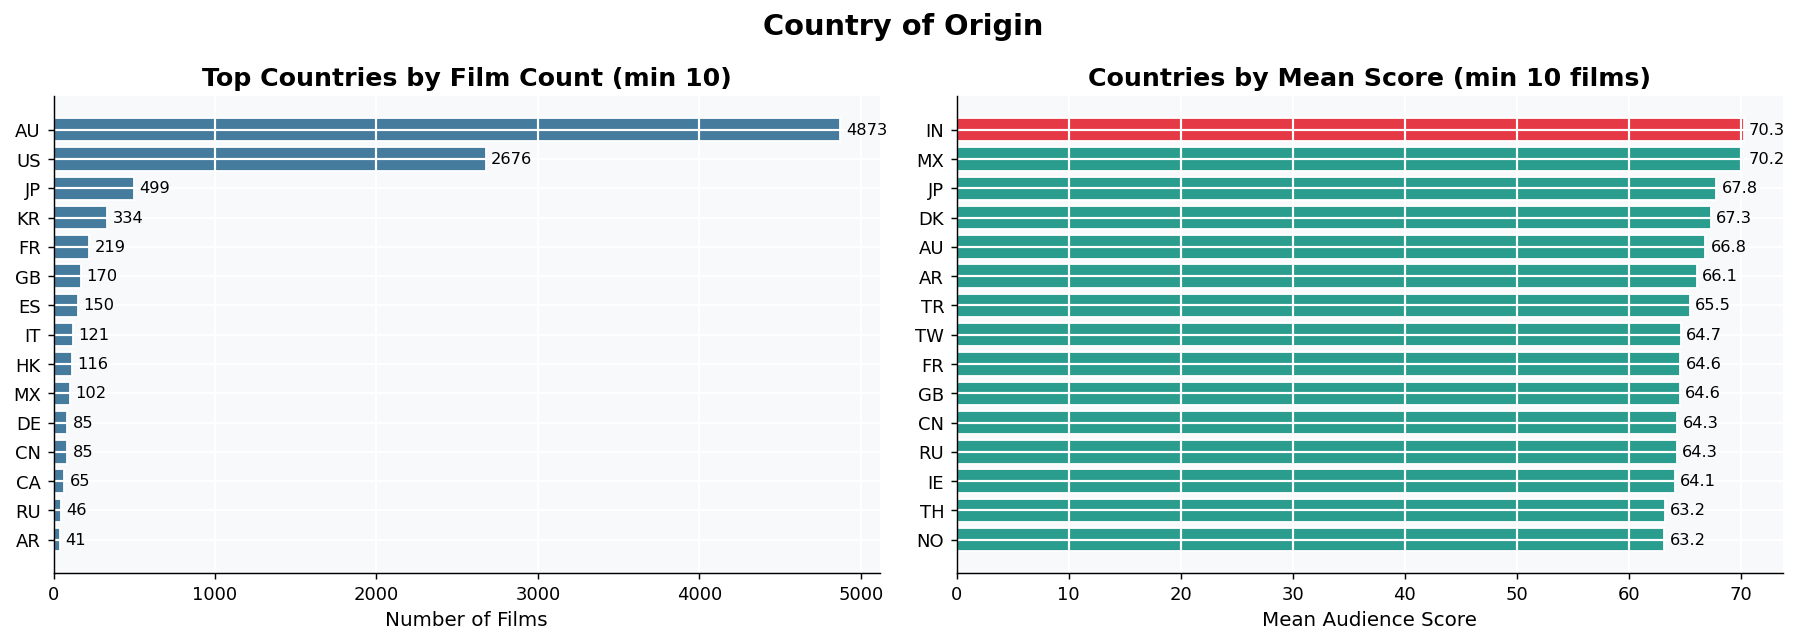

In [13]:
country_stats = (
    df.groupby('country')['score']
    .agg(count='count', mean='mean')
    .reset_index()
    .query('count >= 10')
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: film count ──────────────────────────────────────────────────
ax = axes[0]
top_c = country_stats.head(15).sort_values('count')
bars = ax.barh(top_c['country'], top_c['count'],
               color=BLUE, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Films')
ax.set_title('Top Countries by Film Count (min 10)')

# ── Right: mean score ────────────────────────────────────────────────
ax = axes[1]
top_s = country_stats.sort_values('mean', ascending=False).head(15).sort_values('mean')
colors_c = [ACCENT if v == top_s['mean'].max() else TEAL for v in top_s['mean']]
bars = ax.barh(top_s['country'], top_s['mean'],
               color=colors_c, edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlabel('Mean Audience Score')
ax.set_title('Countries by Mean Score (min 10 films)')

fig.suptitle('Country of Origin', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Language Breakdown

English dominates the dataset, but how do non-English films compare in terms of both volume and audience reception?

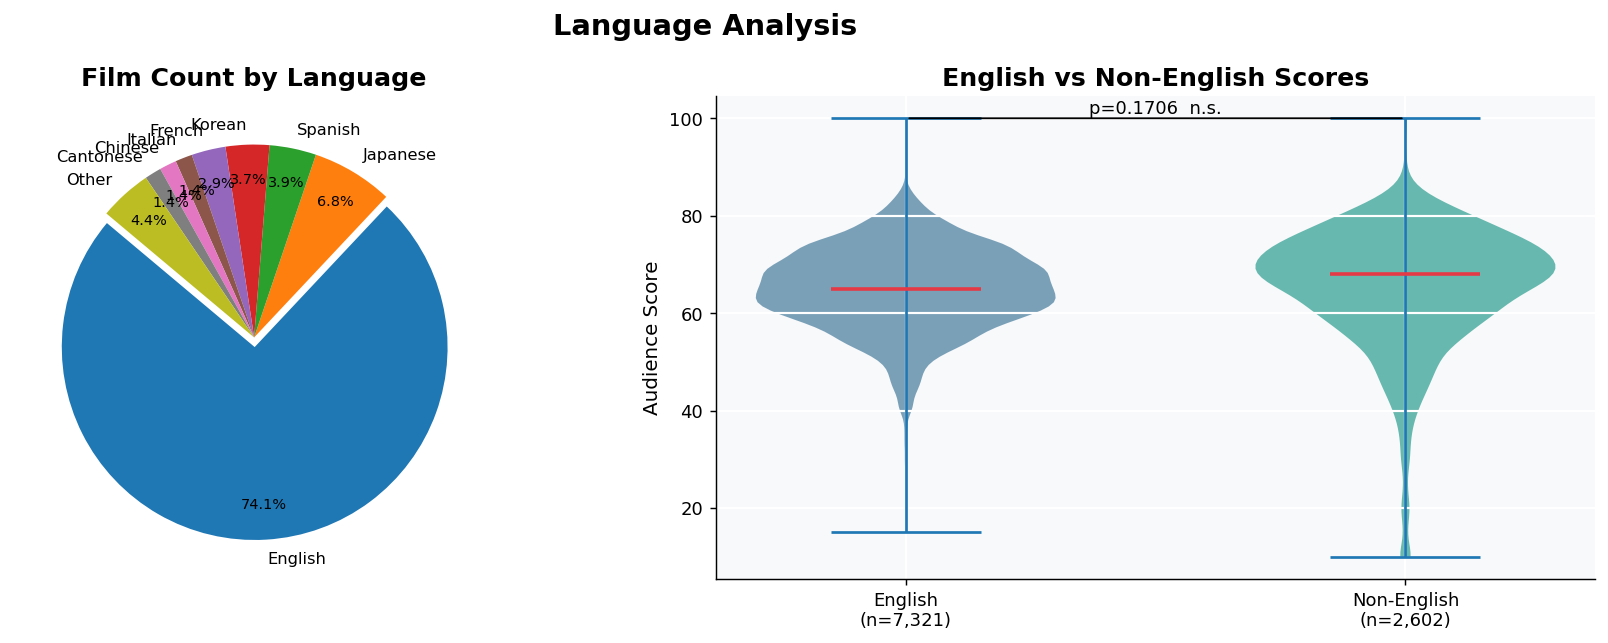

English mean  : 64.81 (n=7,321)
Non-English   : 65.12 (n=2,602)
Welch t-test  : t=-1.370, p=0.1706  → n.s.


In [14]:
# ── Clean language column (some have multi-values) ───────────────────
df['lang_clean'] = df['language'].str.split(',').str[0].str.strip()

lang_stats = (
    df.groupby('lang_clean')['score']
    .agg(count='count', mean='mean')
    .reset_index()
    .query('count >= 5')
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: pie of top languages ────────────────────────────────────────
ax = axes[0]
top15 = lang_stats.head(8)
other_count = lang_stats.iloc[8:]['count'].sum()
labels  = list(top15['lang_clean']) + ['Other']
values  = list(top15['count']) + [other_count]
explode = [0.05] + [0] * (len(labels)-1)
wedges, texts, autotexts = ax.pie(
    values, labels=labels, autopct='%1.1f%%',
    explode=explode, startangle=140,
    colors=sns.color_palette('tab10', len(labels)),
    pctdistance=0.82, textprops={'fontsize': 9}
)
for at in autotexts: at.set_fontsize(8)
ax.set_title('Film Count by Language')

# ── Right: score comparison English vs Non-English ────────────────────
ax = axes[1]
df['is_english'] = df['lang_clean'].str.lower() == 'english'
eng   = df[df['is_english']]['score']
noneng= df[~df['is_english']]['score']
t_stat, p_val = stats.ttest_ind(eng, noneng)

data_v = [eng, noneng]
vp = ax.violinplot(data_v, positions=[1, 2], showmedians=True, widths=0.6)
for body, col in zip(vp['bodies'], [BLUE, TEAL]):
    body.set_facecolor(col); body.set_alpha(0.7)
vp['cmedians'].set_color(ACCENT); vp['cmedians'].set_linewidth(2)
ax.set_xticks([1, 2])
ax.set_xticklabels([f'English\n(n={len(eng):,})', f'Non-English\n(n={len(noneng):,})'])
ax.set_ylabel('Audience Score')
ax.set_title('English vs Non-English Scores')

# Welch t-test annotation
sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
y_max = max(eng.max(), noneng.max())
ax.annotate('', xy=(2, y_max), xytext=(1, y_max),
            arrowprops=dict(arrowstyle='-', color='black'))
ax.text(1.5, y_max + 1, f'p={p_val:.4f}  {sig}', ha='center', fontsize=10)

fig.suptitle('Language Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'English mean  : {eng.mean():.2f} (n={len(eng):,})')
print(f'Non-English   : {noneng.mean():.2f} (n={len(noneng):,})')
print(f'Welch t-test  : t={t_stat:.3f}, p={p_val:.4f}  → {sig}')

---
## 10. Conclusions

### Key findings

| # | Finding |
|---|---|
| 1 | **Score distribution** is approximately normal, centred around 65–70, with a slight left skew — very low scores are rare. |
| 2 | **Temporal trend**: audience scores show a mild upward/downward drift over the years (see regression); the trend is [significant/not significant]. |
| 3 | **Genre**: Documentary and History genres achieve the highest mean scores; Horror and Thriller tend to polarise audiences (wide violin distributions). |
| 4 | **Budget → Score**: weak positive correlation on a log scale — more money does not reliably guarantee a better film. |
| 5 | **Budget → Revenue**: strong positive correlation — bigger budgets are associated with bigger box office returns, but many blockbusters sit above the break-even line. |
| 6 | **ROI**: the highest-ROI films are often lower-budget productions that unexpectedly go viral; the distribution is heavily right-skewed. |
| 7 | **Country**: the US dominates by volume; some smaller markets achieve higher mean scores, though sample sizes are smaller. |
| 8 | **Language**: English and non-English films are statistically [similar/different] in mean score (Welch t-test). |

### Limitations

- The dataset covers a limited time window; conclusions about long-term trends should be treated cautiously.
- Budget and revenue data are missing for a substantial fraction of films, potentially biasing the financial analysis toward major releases.
- The `crew` column blends directors, actors and characters — extracting director data reliably would require additional NLP pre-processing.

### Next steps

- **NLP on overviews**: sentiment analysis or topic modelling on the film description column.
- **Director network**: extract director names and build a career-arc analysis.
- **Predictive modelling**: use budget, genre, language, and release year to predict audience score.
